In [1]:
import os
from omegaconf import OmegaConf

from models import utils
from run_evaluation_summary import Model

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
experiment_root = "experiments"
trained_model_root = "trained_model"
sample_image = "samples/0000310_03000_d_0000124.jpg" #"samples/1f0e643b125f00ec.jpg"
model_name = "tough_river"
model_tag = "best_map"
optimized_cpu_inference = True

In [3]:
cfg = utils.load_model_yaml(model_name, experiment_root)
model_path = utils.find_model_pth_paths(trained_model_root, model_name, model_tag)
cfg.model.metadata.best_model_folder = os.path.dirname(model_path[0])
if OmegaConf.select(cfg, "model.attention_type") is not None:
    attention_type = cfg.model.attention_type
    print("attention_type:", attention_type)
else:
    print("attention_type does not exist")
    cfg.model.attention_type = None
inference_model_name = os.path.splitext(os.path.basename(model_path[0]))[0]
model = Model(cfg, model_name=inference_model_name, optimized_cpu_inference=optimized_cpu_inference)

attention_type does not exist
{'checkpoint': {'dir': 'checkpoints', 'version': 'version_0'}, 'dataset': {'download': 'import os\nfrom pathlib import Path\nimport shutil\n\nfrom ultralytics.utils.downloads import download\nfrom ultralytics.utils import ASSETS_URL, TQDM\n\ndef visdrone2yolo(dir, split, source_name=None):\n    """Convert VisDrone annotations to YOLO format with images/{split} and labels/{split} structure."""\n    from PIL import Image\n\n    source_dir = dir / (source_name or f"VisDrone2019-DET-{split}")\n    images_dir = dir / "images" / split\n    labels_dir = dir / "labels" / split\n    labels_dir.mkdir(parents=True, exist_ok=True)\n\n    # Move images to new structure\n    if (source_images_dir := source_dir / "images").exists():\n        images_dir.mkdir(parents=True, exist_ok=True)\n        for img in source_images_dir.glob("*.jpg"):\n            img.rename(images_dir / img.name)\n\n    for f in TQDM((source_dir / "annotations").glob("*.txt"), desc=f"Converting {spl

/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/albertomarengo/Bitstrapped-Project/my_yolo/yol-venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Freezing conv1.weight
Freezing bn1.weight
Freezing bn1.bias
Freezing layer1.0.conv1.weight
Freezing layer1.0.bn1.weight
Freezing layer1.0.bn1.bias
Freezing layer1.0.conv2.weight
Freezing layer1.0.bn2.weight
Freezing layer1.0.bn2.bias
Freezing layer1.1.conv1.weight
Freezing layer1.1.bn1.weight
Freezing layer1.1.bn1.bias
Freezing layer1.1.conv2.weight
Freezing layer1.1.bn2.weight
Freezing layer1.1.bn2.bias
Freezing layer1.2.conv1.weight
Freezing layer1.2.bn1.weight
Freezing layer1.2.bn1.bias
Freezing layer1.2.conv2.weight
Freezing layer1.2.bn2.weight
Freezing layer1.2.bn2.bias
Freezing fc.weight
Freezing fc.bias


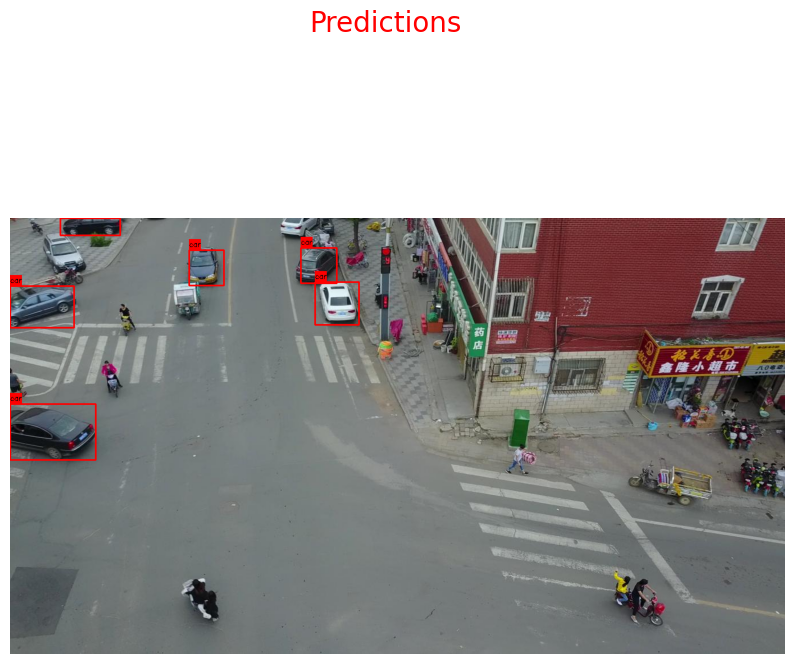

In [8]:
nms_threshold = 0.4
score_threshold = 0.75
pred = model(sample_image, nms_threshold=nms_threshold, score_threshold=score_threshold)
figure = utils.plot_predictions(pred)